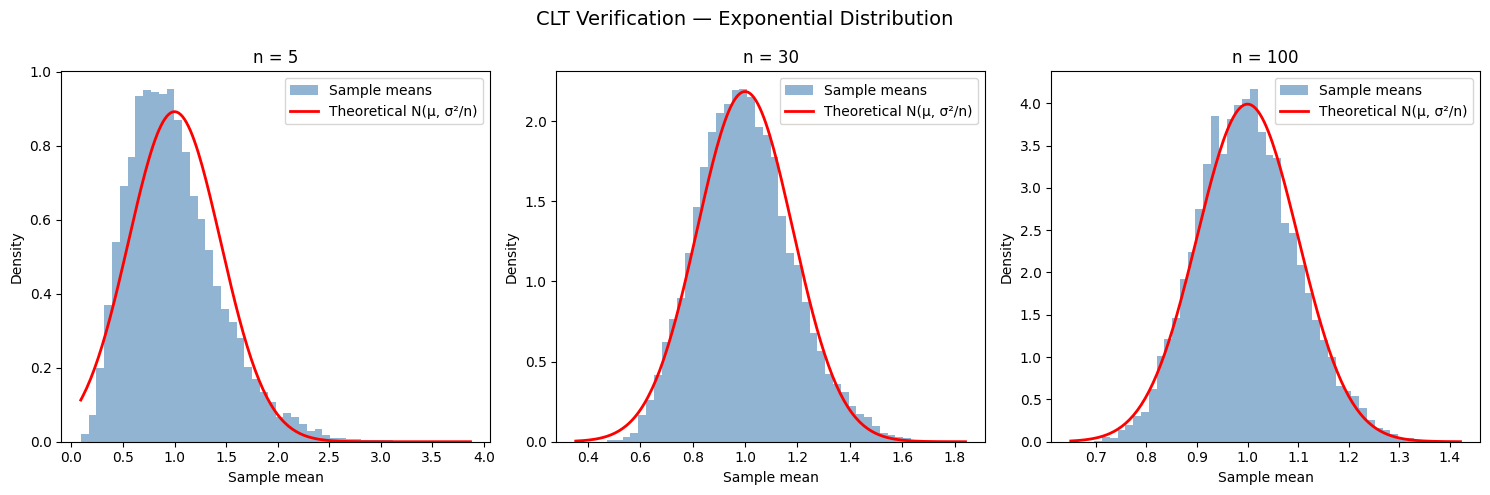

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

lam = 1.0  # rate parameter, so true mean = 1/lam = 1

n_simulations = 10_000
sample_sizes = [5, 30, 100]

sample_means = {}

for n in sample_sizes:
    samples = np.random.exponential(scale=1/lam, size=(10000,n))
    sample_means[n] = samples.mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n in zip(axes, sample_sizes):
    data = sample_means[n]
    
    ax.hist(data, bins=50, density=True, color='steelblue', alpha=0.6, label='Sample means')
    
    mu = 1/lam         
    sigma = (1/lam) / np.sqrt(n)   
    x = np.linspace(data.min(), data.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Theoretical N(μ, σ²/n)')
    
    ax.set_title(f'n = {n}')
    ax.set_xlabel('Sample mean')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('CLT Verification — Exponential Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('clt_verification.png', dpi=150)
plt.show()






                                                                

# CLT Verification — Exponential Distribution

## What this simulation does
The simulation helps visualize the central limit theorem by showing varying sample sizes on and exponential parent distribution and show how incresing the sample size pushed the sampling distribution of the mean from exponential to appproximately normal

## Why exponential?
This is the parent distribution which is heavily skewed right so it will take a larger sample size to get it to normal

## What the plots show
- **n=5**: heavily skewed right and fat onesided tail
- **n=30**: slightly skewed righ and tails which taper off rel. slow
- **n=100**: approx. normal and tails whcih taper off exponentially

## Why this matters for backtesting
This matters because when conducting confidence intervals of the P&L of the account over a time period we want the distribution to be approx normal so that we can use the 68-95-99.7 rule. Also if the trades are not truly independent of eachother then the CLT cannot apply and break approximation even if n is large. 